In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/raw_dataset.csv')

# 1. Konversi Timestamp ke Datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Membersihkan kolom 'Resolved Duration (minutes)'
# Format asli menggunakan '.' untuk ribuan dan ',' untuk desimal (contoh: 8.713,37)
df['Resolved Duration (minutes)'] = (
    df['Resolved Duration (minutes)']
    .str.replace('.', '', regex=False)  # Hapus pemisah ribuan
    .str.replace(',', '.', regex=False)  # Ganti koma desimal ke titik
    .astype(float)
)

print(f"Dataset Shape: {df.shape}")
print(df.info())
display(df.head())

# Cek Missing Values
print("\nMissing Values per Column:")
print(df.isnull().sum())

Dataset Shape: (39259, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39259 entries, 0 to 39258
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   NO                           39259 non-null  int64         
 1   Timestamp                    39259 non-null  datetime64[ns]
 2   Service Type                 37747 non-null  object        
 3   Service Name                 37860 non-null  object        
 4   Type                         39259 non-null  object        
 5   Priority                     39259 non-null  int64         
 6   Impact                       39259 non-null  int64         
 7   Status                       39259 non-null  object        
 8   SLA (minutes)                33679 non-null  float64       
 9   Resolved Time                39259 non-null  object        
 10  Resolved Duration (minutes)  39259 non-null  float64       
 11  Month         

,NO,Timestamp,Service Type,Service Name,Type,Priority,Impact,Status,SLA (minutes),Resolved Time,Resolved Duration (minutes),Month
0,2045,2024-01-01 08:13:45,Inbound,Inbound Contact Center,Restoration,2,2,Closed,45.0,2024-01-01 08:48:06,33.12,Jan
1,2566,2024-01-10 15:06:49,-,-,Restoration,2,2,Closed,90.0,2024-01-11 16:10:11,12.33,Jan
2,2268,2024-01-05 06:11:00,-,-,Restoration,1,1,Closed,210.0,2024-01-05 06:54:47,34.30,Jan
3,2560,2024-01-10 14:19:44,-,-,Restoration,1,1,Closed,210.0,2024-01-10 16:13:57,15.73,Jan
4,2558,2024-01-10 14:02:29,Sosiomedio,Sosiomedio,Restoration,1,1,Closed,210.0,2024-01-10 16:14:56,26.33,Jan



Missing Values per Column:
NO                                0
Timestamp                         0
Service Type                   1512
Service Name                   1399
Type                              0
Priority                          0
Impact                            0
Status                            0
SLA (minutes)                  5580
Resolved Time                     0
Resolved Duration (minutes)       0
Month                             0
dtype: int64


C:\Users\Mahesa\AppData\Local\Temp\ipykernel_38312\2486610598.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Priority', ax=axes[0,0], palette='viridis')
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_38312\2486610598.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Impact', ax=axes[0,1], palette='magma')


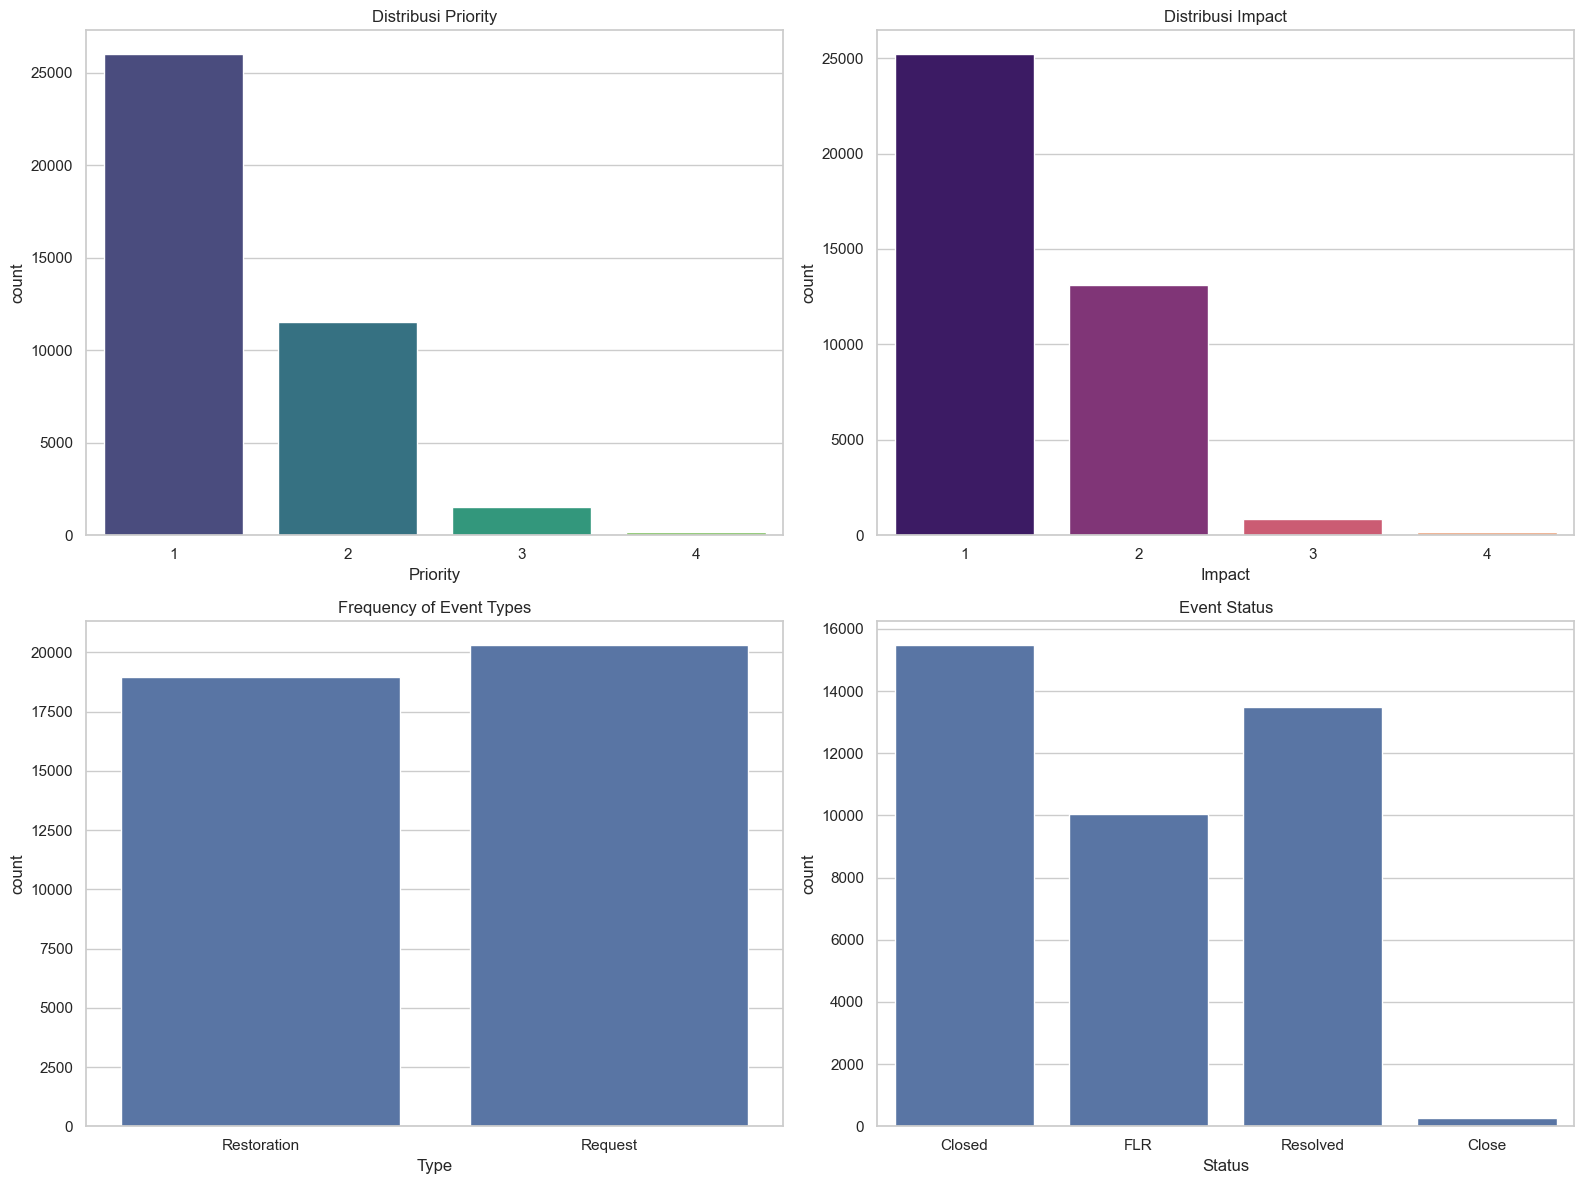

In [2]:
# Setup plot style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Priority Distribution
sns.countplot(data=df, x='Priority', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Distribusi Priority')

# Impact Distribution
sns.countplot(data=df, x='Impact', ax=axes[0,1], palette='magma')
axes[0,1].set_title('Distribusi Impact')

# Event Type (Incident vs Maintenance/Lainnya)
sns.countplot(data=df, x='Type', ax=axes[1,0])
axes[1,0].set_title('Frequency of Event Types')

# Status
sns.countplot(data=df, x='Status', ax=axes[1,1])
axes[1,1].set_title('Event Status')

plt.tight_layout()
plt.show()